## Abdalrahman Mohammed
abmm22@student.bth.se

### Question 1: LSTM Autoencoder-Based Anomaly Detection

##### Requirements

In [1]:
from importlib.metadata import version
import sys
print("PYTHON VERSION:", sys.version)

required_packages = ["numpy", "pandas", "matplotlib", "scikit-learn", "torch"]

print("\nInstalled package versions:")
for package in required_packages:
    print(f"{package} = {version(package)}")

PYTHON VERSION: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

Installed package versions:
numpy = 1.26.4
pandas = 2.3.3
matplotlib = 3.10.7
scikit-learn = 1.7.2
torch = 2.9.1


##### Imports and configuration

In [2]:
import os
import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR = "data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

LABEL_FILE = "labeled_anomalies.csv"

CHANNEL = "A-1"
SEQ_LEN = 50
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001

SEED = 69

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

##### Data preparation

In [3]:
def load_data(channel):
    # create file paths for the selected channel
    train_file = os.path.join(TRAIN_DIR, f"{channel}.npy")
    test_file = os.path.join(TEST_DIR, f"{channel}.npy")

    # load train and test data
    train = np.load(train_file)
    test = np.load(test_file)

    return train, test


def handle_missing_values(data):
    df = pd.DataFrame(data)
    
    # fill missing values using nearby values
    df = df.ffill()
    df = df.bfill()
    
    df = df.fillna(0)   # replace any remaining missing values with 0

    return df.values


def make_sequences(data, seq_len):
    sequences = []

    # create sliding windows
    for i in range(len(data) - seq_len + 1):
        seq = data[i:i + seq_len]
        sequences.append(seq)

    return np.array(sequences)


def split_train_val(data, val_ratio):
    split = int(len(data) * (1 - val_ratio))

    train = data[:split]
    val = data[split:]

    return train, val


train_raw, test_raw = load_data(CHANNEL)

print("Train shape:", train_raw.shape)
print(f"Test shape: {test_raw.shape} \n")

train_clean = handle_missing_values(train_raw)
test_clean = handle_missing_values(test_raw)

print("Missing values in train:", np.isnan(train_clean).sum())
print(f"Missing values in test: {np.isnan(test_clean).sum()} \n")

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_clean)
test_scaled = scaler.transform(test_clean)

print("Scaled train mean:", train_scaled.mean())
print(f"Scaled train std: {train_scaled.std()} \n")

train_sequences = make_sequences(train_scaled, SEQ_LEN)
test_sequences = make_sequences(test_scaled, SEQ_LEN)

print("Train sequences shape:", train_sequences.shape)
print(f"Test sequences shape: {test_sequences.shape} \n")

X_train, X_val = split_train_val(train_sequences, 0.2)
X_test = test_sequences

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Train shape: (2880, 25)
Test shape: (8640, 25) 

Missing values in train: 0
Missing values in test: 0 

Scaled train mean: -2.3067967289433807e-18
Scaled train std: 0.8485281374238569 

Train sequences shape: (2831, 50, 25)
Test sequences shape: (8591, 50, 25) 

X_train: (2264, 50, 25)
X_val: (567, 50, 25)
X_test: (8591, 50, 25)


##### Test label preparation

In [4]:
labels = pd.read_csv(LABEL_FILE)


def make_point_labels(labels, channel, test_length):
    """
    create point level labels for the test data
    0 = normal point
    1 = anomaly point
    """
    y = np.zeros(test_length)

    row = labels[labels["chan_id"] == channel]

    # get the anomaly intervals for this channel
    anomaly_sequences = row.iloc[0]["anomaly_sequences"]
    anomaly_sequences = ast.literal_eval(anomaly_sequences)

    # mark all time points inside each anomaly interval as 1
    for start, end in anomaly_sequences:
        y[start:end + 1] = 1

    return y


y_point = make_point_labels(labels, CHANNEL, len(test_scaled))

print("Number of anomaly points:", int(y_point.sum()))
print(f"Number of normal points: {int(len(y_point) - y_point.sum())} \n")

y_test = y_point[SEQ_LEN - 1:].astype(int)

print("Sequence labels shape:", y_test.shape)
print("Anomalous sequences:", int(y_test.sum()))
print("Normal sequences:", int(len(y_test) - y_test.sum()))
print("X_test sequences:", len(X_test))

Number of anomaly points: 85
Number of normal points: 8555 

Sequence labels shape: (8591,)
Anomalous sequences: 85
Normal sequences: 8506
X_test sequences: 8591


##### Dataloader

In [5]:
train_tensor = torch.tensor(X_train, dtype=torch.float32)
val_tensor = torch.tensor(X_val, dtype=torch.float32)
test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 36
Validation batches: 9
Test batches: 135


##### Simple LSTM autoencoder

In [6]:
class SimpleLSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, code_size, seq_len):
        super().__init__()

        self.seq_len = seq_len

        # encoder
        self.encoder_lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.encoder_fc = nn.Linear(hidden_size, code_size)

        # decoder
        self.decoder_fc = nn.Linear(code_size, hidden_size)
        self.decoder_lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        # encode the input sequence
        _, (hidden, _) = self.encoder_lstm(x)

        # use the last hidden state
        hidden = hidden[-1]

        code  = self.encoder_fc(hidden)

        decoder_input = self.decoder_fc(code )

        decoder_input = decoder_input.unsqueeze(1).repeat(1, self.seq_len, 1)

        decoded, _ = self.decoder_lstm(decoder_input)

        # reconstruct original features
        output = self.output_layer(decoded)

        return output

##### Deeper LSTM autoencoder

In [7]:
class DeepLSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, code_size, seq_len, dropout):
        super().__init__()

        self.seq_len = seq_len

        # deeper encoder with 2 LSTM layers
        self.encoder_lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=2, dropout=dropout, batch_first=True)
        self.encoder_fc = nn.Sequential(nn.Linear(hidden_size, code_size), nn.ReLU())

        # deeper decoder with 2 LSTM layers
        self.decoder_fc = nn.Sequential(nn.Linear(code_size, hidden_size), nn.ReLU())
        self.decoder_lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, num_layers=2, dropout=dropout, batch_first=True)

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        # encode the input sequence
        _, (hidden, _) = self.encoder_lstm(x)

        # use the last hidden state
        hidden = hidden[-1]

        latent = self.encoder_fc(hidden)

        decoder_input = self.decoder_fc(latent)

        decoder_input = decoder_input.unsqueeze(1).repeat(1, self.seq_len, 1)

        decoded, _ = self.decoder_lstm(decoder_input)

        # reconstruct original features
        output = self.output_layer(decoded)

        return output

##### Model training

In [8]:
def train_model(model, train_loader, val_loader, epochs, learning_rate):
    loss_function  = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_loss_list  = []
    val_loss_list  = []

    for epoch in range(epochs):
        # training phase
        model.train()
        total_train_loss = 0

        for batch in train_loader:
            x = batch[0]

            optimizer.zero_grad()

            
            output  = model(x)                  # reconstruct the input sequence
            loss = loss_function (output, x)    # compare reconstructed output with original input

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * x.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_loss_list .append(avg_train_loss)

        # validation phase
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                x = batch[0]

                output = model(x)
                loss = loss_function (output, x)

                total_val_loss += loss.item() * x.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_loss_list .append(avg_val_loss)

        print(f"Epoch [{epoch + 1}/{epochs}] Train Loss: {avg_train_loss:.6f} Val Loss: {avg_val_loss:.6f}")

    return model, train_loss_list , val_loss_list 


input_size = X_train.shape[2]

model_simple = SimpleLSTMAutoencoder(input_size=input_size, hidden_size=64, code_size=32, seq_len=SEQ_LEN)

model_deep = DeepLSTMAutoencoder(input_size=input_size, hidden_size=128, code_size=64, seq_len=SEQ_LEN, dropout=0.2)

print("Training Simple LSTM Autoencoder")
model_simple, simple_train_losses, simple_val_losses = train_model(model_simple, train_loader, val_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE)

print("Training Deep LSTM Autoencoder")
model_deep, deep_train_losses, deep_val_losses = train_model(model_deep, train_loader, val_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE)

Training Simple LSTM Autoencoder
Epoch [1/50] Train Loss: 0.749132 Val Loss: 0.506150
Epoch [2/50] Train Loss: 0.741870 Val Loss: 0.498070
Epoch [3/50] Train Loss: 0.739076 Val Loss: 0.497145
Epoch [4/50] Train Loss: 0.737362 Val Loss: 0.496949
Epoch [5/50] Train Loss: 0.735237 Val Loss: 0.496203
Epoch [6/50] Train Loss: 0.732703 Val Loss: 0.493923
Epoch [7/50] Train Loss: 0.730052 Val Loss: 0.491008
Epoch [8/50] Train Loss: 0.703513 Val Loss: 0.462791
Epoch [9/50] Train Loss: 0.680025 Val Loss: 0.439754
Epoch [10/50] Train Loss: 0.671724 Val Loss: 0.431907
Epoch [11/50] Train Loss: 0.655278 Val Loss: 0.427167
Epoch [12/50] Train Loss: 0.650227 Val Loss: 0.436936
Epoch [13/50] Train Loss: 0.648273 Val Loss: 0.423804
Epoch [14/50] Train Loss: 0.635864 Val Loss: 0.442111
Epoch [15/50] Train Loss: 0.638101 Val Loss: 0.409437
Epoch [16/50] Train Loss: 0.615879 Val Loss: 0.402715
Epoch [17/50] Train Loss: 0.629900 Val Loss: 0.413586
Epoch [18/50] Train Loss: 0.623033 Val Loss: 0.401677
Epoc

##### Plot training and validation loss

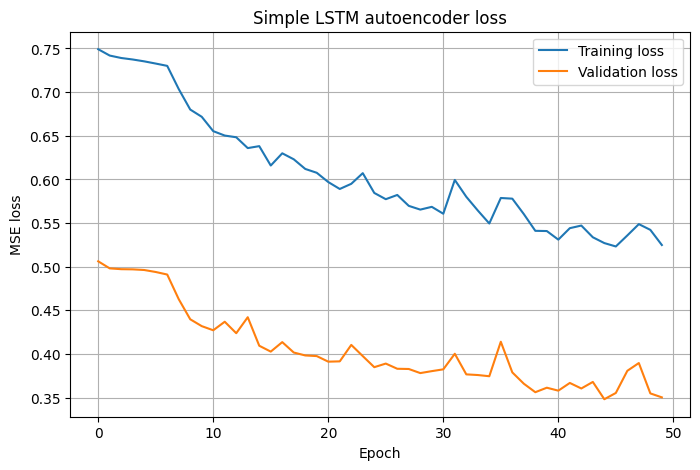

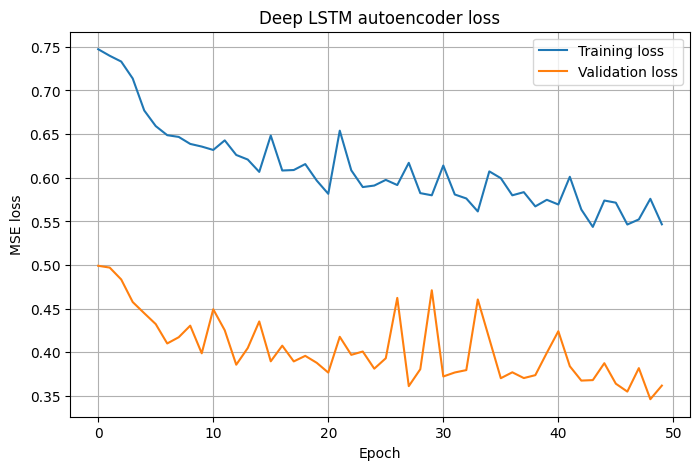

In [9]:
def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Training loss")
    plt.plot(val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_losses(simple_train_losses, simple_val_losses, "Simple LSTM autoencoder loss")
plot_losses(deep_train_losses, deep_val_losses, "Deep LSTM autoencoder loss")

##### Threshold selection

In [10]:
def get_reconstruction_errors(model, data_loader):
    model.eval()
    error_list  = []

    with torch.no_grad():
        for batch in data_loader:
            x = batch[0]

            output  = model(x)

            # calculate mean squared error for each sequence
            batch_errors = torch.mean((x - output ) ** 2, dim=(1, 2))

            error_list .extend(batch_errors.numpy())

    return np.array(error_list )


def evaluate_thresholds_from_validation(y_true, test_errors, val_errors, percentiles):
    results = []

    for percentile in percentiles:
        threshold = np.percentile(val_errors, percentile)
        pred = (test_errors > threshold).astype(int)

        results.append({"Percentile": percentile, "Threshold": threshold, "Detected anomalies": int(pred.sum()), "Precision": precision_score(y_true, pred, zero_division=0),
                     "Recall": recall_score(y_true, pred, zero_division=0), "F1-score": f1_score(y_true, pred, zero_division=0)})

    return pd.DataFrame(results)


# calculate reconstruction errors
simple_val_errors = get_reconstruction_errors(model_simple, val_loader)
simple_test_errors = get_reconstruction_errors(model_simple, test_loader)

deep_val_errors = get_reconstruction_errors(model_deep, val_loader)
deep_test_errors = get_reconstruction_errors(model_deep, test_loader)


# compare thresholds
simple_results  = evaluate_thresholds_from_validation(y_true=y_test, test_errors=simple_test_errors, val_errors=simple_val_errors, percentiles=[90, 92, 95, 97, 98, 99])
deep_results  = evaluate_thresholds_from_validation(y_true=y_test, test_errors=deep_test_errors, val_errors=deep_val_errors, percentiles=[90, 92, 95, 97, 98, 99])

print("Simple model threshold comparison:")
display(simple_results )

print("Deep model threshold comparison:")
display(deep_results )


# select best thresholds
best_simple_percentile  = 98
best_deep_percentile  = 97

simple_threshold = np.percentile(simple_val_errors, best_simple_percentile)
deep_threshold = np.percentile(deep_val_errors, best_deep_percentile)

simple_pred = (simple_test_errors > simple_threshold).astype(int)
deep_pred = (deep_test_errors > deep_threshold).astype(int)

Simple model threshold comparison:


,Percentile,Threshold,Detected anomalies,Precision,Recall,F1-score
0,90,1.257239,1056,0.045455,0.564706,0.084137
1,92,1.333906,1008,0.047619,0.564706,0.087832
2,95,1.408370,898,0.053452,0.564706,0.097660
3,97,1.478639,789,0.055767,0.517647,0.100686
4,98,1.996037,418,0.069378,0.341176,0.115308
5,99,2.116560,366,0.051913,0.223529,0.084257


Deep model threshold comparison:


,Percentile,Threshold,Detected anomalies,Precision,Recall,F1-score
0,90,1.293288,995,0.044221,0.517647,0.081481
1,92,1.353172,909,0.048405,0.517647,0.088531
2,95,1.487230,808,0.054455,0.517647,0.098544
3,97,1.544761,735,0.059864,0.517647,0.107317
4,98,2.162374,366,0.060109,0.258824,0.097561
5,99,2.493258,231,0.000000,0.000000,0.000000


##### Visualize reconstruction error over time

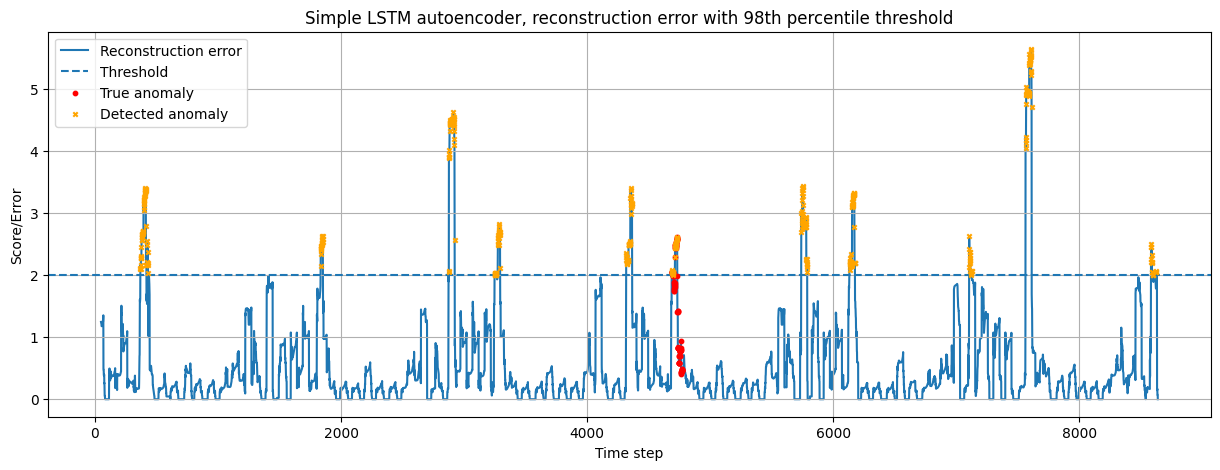

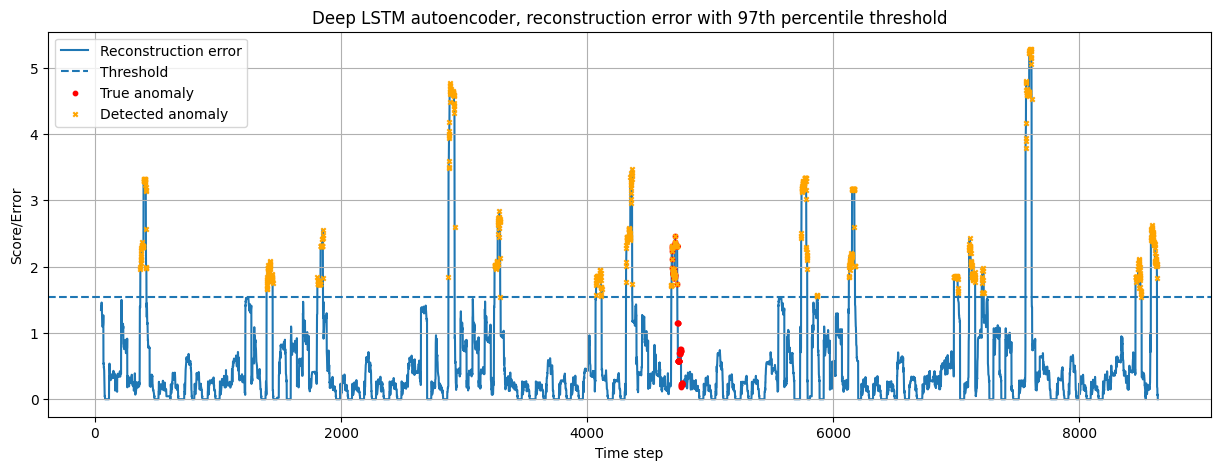

In [11]:
def plot_errors(errors, threshold, y_true, y_pred, title):
    time = np.arange(len(errors)) + SEQ_LEN - 1       # align sequence errors with the original time steps

    plt.figure(figsize=(15, 5))

    # plot reconstruction error and threshold
    plt.plot(time, errors, label="Reconstruction error", zorder=1)
    plt.axhline(y=threshold, linestyle="--", label="Threshold", zorder=2)

    # plot true anomalies
    true_time = time[y_true == 1]
    true_errors = errors[y_true == 1]

    plt.scatter(true_time, true_errors, s=10, color="red", label="True anomaly", zorder=3)

    # plot detected anomalies
    pred_time = time[y_pred == 1]
    pred_errors = errors[y_pred == 1]

    plt.scatter(pred_time, pred_errors, s=10, color="orange", marker="x", label="Detected anomaly", zorder=4)

    plt.xlabel("Time step")
    plt.ylabel("Score/Error")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_errors(errors=simple_test_errors, threshold=simple_threshold, y_true=y_test, y_pred=simple_pred,
            title=f"Simple LSTM autoencoder, reconstruction error with {best_simple_percentile}th percentile threshold")

plot_errors(errors=deep_test_errors,threshold=deep_threshold,y_true=y_test,y_pred=deep_pred,
            title=f"Deep LSTM autoencoder, reconstruction error with {best_deep_percentile}th percentile threshold")

##### Compare models in one summary table

In [12]:
def get_metrics(y_true, errors, pred):
    precision = precision_score(y_true, pred, zero_division=0)
    recall = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, errors)

    return {"Mean Score/Error": errors.mean(), "Precision": precision, "Recall": recall, "F1-score": f1, "ROC-AUC": roc_auc}
    
results = pd.DataFrame({f"Simple LSTM autoencoder ({best_simple_percentile}th percentile)": get_metrics(y_test,simple_test_errors,simple_pred),
                        f"Deep LSTM autoencoder ({best_deep_percentile}th percentile)": get_metrics(y_test,deep_test_errors,deep_pred)}).T

results

,Mean Score/Error,Precision,Recall,F1-score,ROC-AUC
Simple LSTM autoencoder (98th percentile),0.534624,0.069378,0.341176,0.115308,0.867053
Deep LSTM autoencoder (97th percentile),0.530836,0.059864,0.517647,0.107317,0.823316


### Question 2: Baseline Model Comparison

##### K-Means Clustering

X_train_flat shape: (2264, 1250)
X_val_flat shape: (567, 1250)
X_test_flat shape: (8591, 1250) 

Validation anomaly error mean: 20.091265608220233
Test anomaly error mean: 23.694593554369856 

K-Means threshold comparison:


,Percentile,Threshold,Detected anomalies,Precision,Recall,F1-score
0,90,41.620874,1073,0.041007,0.517647,0.075993
1,92,43.770159,876,0.050228,0.517647,0.091571
2,95,43.995389,844,0.052133,0.517647,0.094726
3,97,44.755364,747,0.058902,0.517647,0.105769
4,98,53.286861,363,0.052342,0.223529,0.084821
5,99,54.403589,295,0.010169,0.035294,0.015789


Best K-Means threshold: 44.755364222863186
Detected anomalies: 747


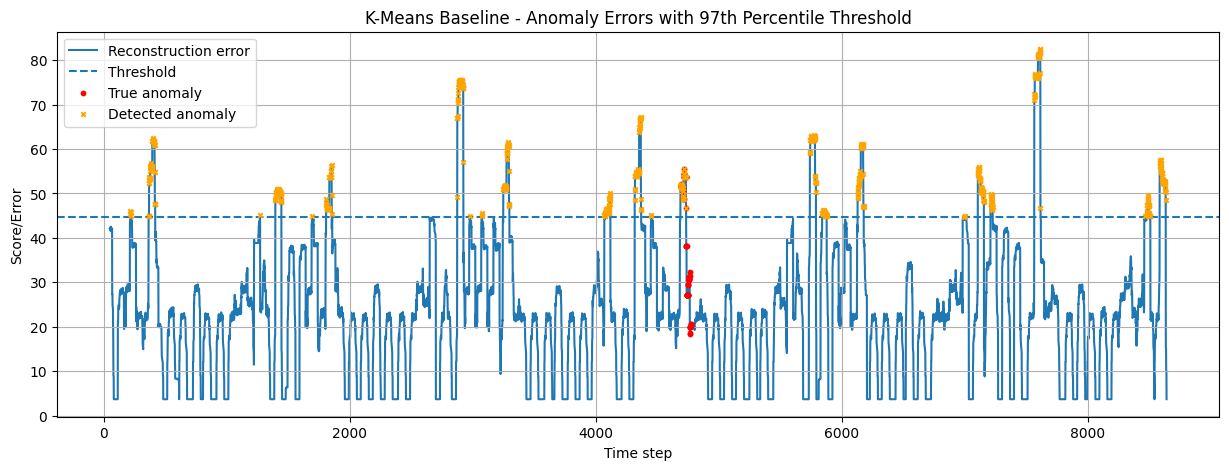

,Mean Score/Error,Precision,Recall,F1-score,ROC-AUC
Simple LSTM autoencoder (98th percentile),0.534624,0.069378,0.341176,0.115308,0.867053
Deep LSTM autoencoder (97th percentile),0.530836,0.059864,0.517647,0.107317,0.823316
K-Means baseline (97th percentile),23.694594,0.058902,0.517647,0.105769,0.797020


In [13]:
# flatten sequences from 3D to 2D because K-Means needs 2D input
train_flat  = X_train.reshape(X_train.shape[0], -1)
val_flat  = X_val.reshape(X_val.shape[0], -1)
test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat shape: {train_flat.shape}")
print(f"X_val_flat shape: {val_flat.shape}")
print(f"X_test_flat shape: {test_flat.shape} \n")

n_clusters  = 5

kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)

kmeans.fit(train_flat)

kmeans_val_scores  = np.min(kmeans.transform(val_flat), axis=1)
kmeans_test_scores  = np.min(kmeans.transform(test_flat), axis=1)

print("Validation anomaly error mean:", kmeans_val_scores.mean())
print(f"Test anomaly error mean: {kmeans_test_scores.mean()} \n")

kmeans_threshold_results = evaluate_thresholds_from_validation(y_true=y_test, test_errors=kmeans_test_scores, val_errors=kmeans_val_scores, percentiles=[90, 92, 95, 97, 98, 99])

print("K-Means threshold comparison:")
display(kmeans_threshold_results)

best_kmeans_percentile  = 97

kmeans_threshold  = np.percentile(kmeans_val_scores, best_kmeans_percentile)
kmeans_pred  = (kmeans_test_scores > kmeans_threshold).astype(int)

print("Best K-Means threshold:", kmeans_threshold)
print("Detected anomalies:", kmeans_pred.sum())

plot_errors(errors=kmeans_test_scores, threshold=kmeans_threshold, y_true=y_test, y_pred=kmeans_pred,
            title=f"K-Means Baseline - Anomaly Errors with {best_kmeans_percentile}th Percentile Threshold")

final_results = pd.DataFrame({f"Simple LSTM autoencoder ({best_simple_percentile}th percentile)": get_metrics(y_test, simple_test_errors,simple_pred),
                              f"Deep LSTM autoencoder ({best_deep_percentile}th percentile)": get_metrics(y_test, deep_test_errors, deep_pred),
                              f"K-Means baseline ({best_kmeans_percentile}th percentile)": get_metrics(y_test, kmeans_test_scores, kmeans_pred)}).T

final_results